In [1]:
!pip -q install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "samehraouf/jena-climate-time-series-2009-2017-dataset"
)

print(path)

100%|██████████| 6.26M/6.26M [00:00<00:00, 205MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/samehraouf/jena-climate-time-series-2009-2017-dataset/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/root/.cache/kagglehub/datasets/samehraouf/jena-climate-time-series-2009-2017-dataset/versions/1/jena_climate_2009_2017.csv


In [4]:
import pandas as pd

csv_file = [
    os.path.join(root, file)
    for root, dirs, files in os.walk(path)
    for file in files
    if file.endswith(".csv")
][0]

df = pd.read_csv(csv_file)

print(df.shape)
df.head()

(420551, 7)


,Date Time,p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),T (degC)
0,01.01.2009 00:10:00,996.52,93.3,1.03,1.75,152.3,-8.02
1,01.01.2009 00:20:00,996.57,93.4,0.72,1.50,136.1,-8.41
2,01.01.2009 00:30:00,996.53,93.9,0.19,0.63,171.6,-8.51
3,01.01.2009 00:40:00,996.51,94.2,0.34,0.50,198.0,-8.31
4,01.01.2009 00:50:00,996.51,94.1,0.32,0.63,214.3,-8.27


In [5]:
df = df.iloc[::6].reset_index(drop=True)

In [6]:
print(df.shape)

(70092, 7)


In [7]:
features = [
    "p (mbar)",
    "T (degC)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

data = df[features].copy()

data.head()

,p (mbar),T (degC),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,996.52,-8.02,93.3,1.03,1.75,152.3
1,996.50,-7.62,94.8,0.18,0.63,166.5
2,996.63,-8.85,93.5,0.16,0.50,158.3
3,996.87,-8.84,93.5,0.07,0.25,129.3
4,997.05,-9.23,92.2,0.10,0.38,203.9


In [8]:
import numpy as np

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

In [9]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_data[features])

target_scaler.fit(
    train_data[["T (degC)"]]
)

StandardScaler()

In [10]:
X_train_scaled = feature_scaler.transform(train_data[features])
X_val_scaled = feature_scaler.transform(val_data[features])
X_test_scaled = feature_scaler.transform(test_data[features])

y_train_scaled = target_scaler.transform(train_data[["T (degC)"]])
y_val_scaled = target_scaler.transform(val_data[["T (degC)"]])
y_test_scaled = target_scaler.transform(test_data[["T (degC)"]])

## Create sequences

In [11]:
SEQ_LEN = 24

def create_sequences(X, y, seq_len=24):

    sequences = []
    targets = []

    for i in range(len(X) - seq_len):

        sequences.append(
            X[i:i + seq_len]
        )

        targets.append(
            y[i + seq_len]
        )

    return (
        np.array(sequences, dtype=np.float32),
        np.array(targets, dtype=np.float32)
    )

In [12]:
X_train, y_train = create_sequences(
    X_train_scaled,
    y_train_scaled,
    SEQ_LEN
)

X_val, y_val = create_sequences(
    X_val_scaled,
    y_val_scaled,
    SEQ_LEN
)

X_test, y_test = create_sequences(
    X_test_scaled,
    y_test_scaled,
    SEQ_LEN
)

print(X_train.shape)
print(y_train.shape)

(49040, 24, 6)
(49040, 1)


In [14]:
import torch

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

train_dataset = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train)
)

val_dataset = TensorDataset(
    torch.tensor(X_val),
    torch.tensor(y_val)
)

test_dataset = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(y_test)
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

## Build LSTM

In [16]:
import torch.nn as nn

class TemperatureLSTM(nn.Module):

    def __init__(
        self,
        input_size=6,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        final_hidden = hidden[-1]

        prediction = self.fc(final_hidden)

        return prediction

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = TemperatureLSTM().to(device)

print(model)

TemperatureLSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## Regression loss

In [18]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## Train

In [19]:
EPOCHS = 10

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/10 Loss: 0.0823
Epoch 2/10 Loss: 0.0171
Epoch 3/10 Loss: 0.0127
Epoch 4/10 Loss: 0.0108
Epoch 5/10 Loss: 0.0099
Epoch 6/10 Loss: 0.0094
Epoch 7/10 Loss: 0.0089
Epoch 8/10 Loss: 0.0087
Epoch 9/10 Loss: 0.0085
Epoch 10/10 Loss: 0.0083


## Test predictions

In [20]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = model(X_batch)

        predictions.extend(
            output.cpu().numpy()
        )

        actuals.extend(
            y_batch.numpy()
        )

## Convert back to Celsius

In [21]:
predictions = target_scaler.inverse_transform(
    np.array(predictions)
)

actuals = target_scaler.inverse_transform(
    np.array(actuals)
)

## RMSE

In [22]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(
    actuals,
    predictions
) ** 0.5

print("RMSE:", rmse, "°C")

RMSE: 0.6856483753848004 °C


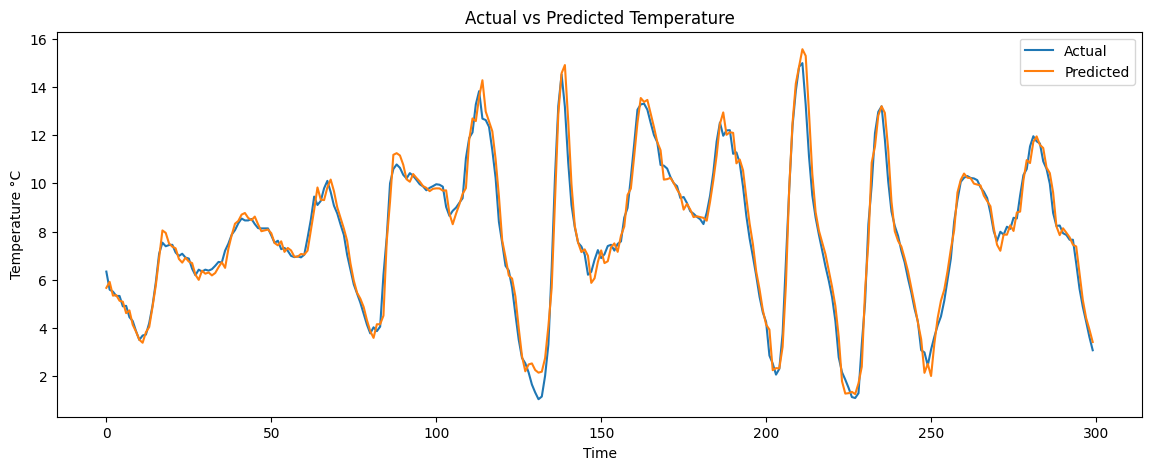

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    actuals[:300],
    label="Actual"
)

plt.plot(
    predictions[:300],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Temperature °C")
plt.title("Actual vs Predicted Temperature")
plt.legend()

plt.show()